# Модель 1. Прогноз спроса — исследование

Гранулярность — **неделя × товар**. Пробовали день × товар: формально строк в 8 раз больше,
но отгрузки идут пачками 2-4 раза в неделю (доля дней с продажами 23-38%), и на дневных тестовых
окнах WAPE становился нестабильным (>1 даже у бейзлайнов). Неделя соответствует реальному ритму
отгрузок, поэтому она основная.

Логика ноутбука — это история эксперимента, а не сразу готовый ответ:
1. Бейзлайны (наивный прогноз, скользящая средняя).
2. **Итерация 1**: обучаем модели на полном наборе фич "что под руку попало" — смотрим, бьём
   ли мы бейзлайны.
3. Если нет — смотрим на важность фич у модели из итерации 1, чтобы понять, что мешает.
4. **Итерация 2**: переобучаем на сокращённом наборе фич по итогам анализа важности.
5. Финальное сравнение всех попыток.

Без финальных выводов в README — это рабочий черновик.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. Загрузка данных и фильтр (реализация без корректировок, только актуальные товары)

In [2]:
DATA_PATH = "../../../Данные/Итоговые таблицы/sales_by_counterparties.parquet"
REFERENCE_PATH = "../../Справочники/справочник_товаров_шаблон.csv"

sales = pd.read_parquet(DATA_PATH)
ref = pd.read_csv(REFERENCE_PATH)
ref_active = ref[ref["актуальность"].fillna("").str.strip().str.lower() == "да"]

print("Всего строк продаж:", sales.shape[0], "| актуальных товаров:", ref_active["общее_название"].nunique())

real = sales[sales["sales_doc_type"] == "Реализация"].merge(
    ref_active[["nomenclature_raw", "общее_название", "срок_годности_дней"]],
    left_on="nomenclature",
    right_on="nomenclature_raw",
    how="inner",
)
print("Строк после фильтра:", real.shape[0])
real[["sale_date", "общее_название", "brand", "quantity", "amount"]].head()

Всего строк продаж: 3051 | актуальных товаров: 3
Строк после фильтра: 2037


,sale_date,общее_название,brand,quantity,amount
0,2025-05-19,Кекс с изюмом,Маяк,100.0,20700.0
1,2025-05-19,Песочное печенье,Маяк,100.0,19660.0
2,2025-05-19,Кекс с изюмом,Маяк,100.0,20700.0
3,2025-05-19,Песочное печенье,Маяк,100.0,19660.0
4,2025-05-19,Кекс с изюмом,Маяк,100.0,20700.0


## 2. Сборка недельного ряда `товар × неделя`

In [3]:
real["week"] = real["sale_date"].dt.to_period("W-MON").apply(lambda p: p.start_time)

weekly_total = (
    real.groupby(["общее_название", "week"], as_index=False)
    .agg(quantity=("quantity", "sum"), amount=("amount", "sum"))
)
weekly_total["price_per_unit"] = weekly_total["amount"] / weekly_total["quantity"]

weekly_by_brand = (
    real.groupby(["общее_название", "week", "brand"], as_index=False)
    .agg(quantity=("quantity", "sum"))
)
brand_pivot = weekly_by_brand.pivot_table(
    index=["общее_название", "week"], columns="brand", values="quantity", fill_value=0
).reset_index()
brand_pivot.columns = [
    f"qty_{c}" if c not in ("общее_название", "week") else c for c in brand_pivot.columns
]

weekly_total = weekly_total.merge(brand_pivot, on=["общее_название", "week"], how="left")

shelf_life = ref_active.groupby("общее_название")["срок_годности_дней"].first()
weekly_total["срок_годности_дней"] = weekly_total["общее_название"].map(shelf_life)

weekly_total.sort_values(["общее_название", "week"]).head(10)

,общее_название,week,quantity,amount,price_per_unit,qty_Маяк,qty_Светофор,срок_годности_дней
0,Ажурная коса,2025-07-22,680.0,170000.0,250.0,0.0,680.0,30.0
1,Ажурная коса,2025-07-29,2241.0,560250.0,250.0,0.0,2241.0,30.0
2,Ажурная коса,2025-08-05,720.0,180000.0,250.0,0.0,720.0,30.0
3,Ажурная коса,2025-08-12,840.0,210000.0,250.0,0.0,840.0,30.0
4,Ажурная коса,2025-08-19,920.0,230000.0,250.0,0.0,920.0,30.0
5,Ажурная коса,2025-08-26,1300.0,325000.0,250.0,0.0,1300.0,30.0
6,Ажурная коса,2025-09-02,990.0,247500.0,250.0,0.0,990.0,30.0
7,Ажурная коса,2025-09-09,1052.0,263000.0,250.0,0.0,1052.0,30.0
8,Ажурная коса,2025-09-16,1360.0,340000.0,250.0,0.0,1360.0,30.0
9,Ажурная коса,2025-09-23,1480.0,370000.0,250.0,0.0,1480.0,30.0


## 3. Заполнение пропущенных недель нулями

In [4]:
def fill_missing_weeks(df: pd.DataFrame) -> pd.DataFrame:
    qty_cols = [c for c in df.columns if c.startswith("qty_")]
    frames = []
    for product, sub in df.groupby("общее_название"):
        full_range = pd.date_range(sub["week"].min(), sub["week"].max(), freq="7D")
        sub_full = (
            sub.set_index("week")
            .reindex(full_range)
            .rename_axis("week")
            .reset_index()
        )
        sub_full["общее_название"] = product
        sub_full["quantity"] = sub_full["quantity"].fillna(0.0)
        sub_full["amount"] = sub_full["amount"].fillna(0.0)
        for col in qty_cols:
            sub_full[col] = sub_full[col].fillna(0.0)
        frames.append(sub_full)
    return pd.concat(frames, ignore_index=True)


weekly_filled = fill_missing_weeks(weekly_total)
weekly_filled["price_per_unit"] = weekly_filled["price_per_unit"].ffill()
weekly_filled["срок_годности_дней"] = weekly_filled["общее_название"].map(shelf_life)

print("Недельных строк после заполнения:", weekly_filled.shape[0])
coverage = weekly_filled.groupby("общее_название")["quantity"].apply(lambda s: (s > 0).mean())
print("Доля недель с продажами по товару:")
print(coverage)

Недельных строк после заполнения: 154
Доля недель с продажами по товару:
общее_название
Ажурная коса        0.875000
Кекс с изюмом       0.879310
Песочное печенье    0.854167
Name: quantity, dtype: float64


## 4. Визуальный осмотр рядов — тренд, сезонность, выбросы

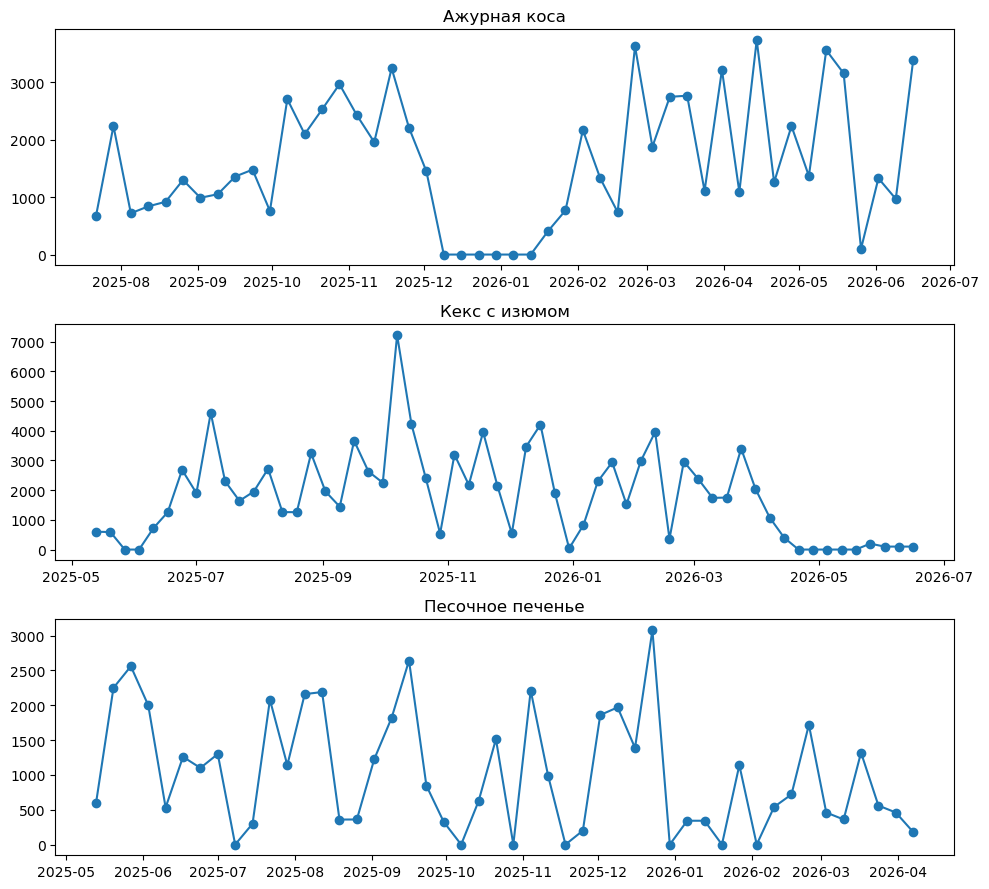

In [5]:
products = weekly_filled["общее_название"].unique()
fig, axes = plt.subplots(len(products), 1, figsize=(10, 3 * len(products)))
if len(products) == 1:
    axes = [axes]
for ax, product in zip(axes, products):
    sub = weekly_filled[weekly_filled["общее_название"] == product].sort_values("week")
    ax.plot(sub["week"], sub["quantity"], marker="o")
    ax.set_title(product)
plt.tight_layout()
plt.show()

## 5. Метрика оптимизации и вспомогательные функции

**WAPE** — основная (взвешивает по объёму, устойчива при разном масштабе товаров и при нулевых
неделях). **MAE** — для интерпретируемости в штуках. Все результаты складываем в один словарь
`results`, чтобы в конце сравнить вообще все попытки (бейзлайны + обе итерации) в одной таблице.

In [6]:
def mae(actual, pred):
    return np.mean(np.abs(actual - pred))


def wape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(np.abs(actual))


def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred) ** 2))


results = {}


def evaluate(name, actual, pred):
    results[name] = {"WAPE": wape(actual, pred), "MAE": mae(actual, pred), "RMSE": rmse(actual, pred)}
    print(name, results[name])

## 6. Построение всех фич-кандидатов

Строим сразу широкий набор фич — лаги (1, 2, 4 недели), скользящие средние/std (4 и 8 недель,
без пересечения границ товаров), календарные признаки, доли продаж по сетям (лаговые), срок
годности, цену, категориальный товар. На итерации 1 используем их все, дальше по важности
будем сокращать — но сам датасет (и train/test split) строим один раз, чтобы обе итерации
сравнивались на одних и тех же строках.

In [7]:
# Праздничные дни РФ по месяцам — фиксированный список без учёта переносов по годам
# (Новогодние каникулы 1-8 янв ~8 дней, 23 февр, 8 марта, 1 и 9 мая, 12 июня, 4 ноября).
HOLIDAYS_PER_MONTH = {1: 8, 2: 1, 3: 1, 4: 0, 5: 2, 6: 1, 7: 0, 8: 0, 9: 0, 10: 0, 11: 1, 12: 0}

BRAND_SHARE_COLS = {"qty_Светофор": "share_светофор", "qty_Маяк": "share_маяк"}


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["общее_название", "week"]).copy()

    def lagged_roll(col: str, window: int, stat: str) -> pd.Series:
        # сдвиг (без утечки текущей недели) + скользящая статистика, не пересекая границы товаров
        shifted = df.groupby("общее_название")[col].shift(1)
        rolled = shifted.groupby(df["общее_название"]).rolling(window)
        return getattr(rolled, stat)().reset_index(level=0, drop=True)

    df["lag_1"] = df.groupby("общее_название")["quantity"].shift(1)
    df["lag_2"] = df.groupby("общее_название")["quantity"].shift(2)
    df["lag_4"] = df.groupby("общее_название")["quantity"].shift(4)
    df["roll_mean_4"] = lagged_roll("quantity", 4, "mean")
    df["roll_mean_8"] = lagged_roll("quantity", 8, "mean")
    df["roll_std_4"] = lagged_roll("quantity", 4, "std")

    df["week_of_year"] = df["week"].dt.isocalendar().week.astype(int)
    df["month"] = df["week"].dt.month
    df["праздничные_дни_в_месяце"] = df["month"].map(HOLIDAYS_PER_MONTH)

    for qty_col, feature_name in BRAND_SHARE_COLS.items():
        if qty_col in df.columns:
            raw_col = f"{feature_name}_raw"
            df[raw_col] = (df[qty_col] / df["quantity"].replace(0, np.nan)).fillna(0)
            df[feature_name] = lagged_roll(raw_col, 4, "mean")

    df["общее_название"] = df["общее_название"].astype("category")
    return df


featured = build_features(weekly_filled)
required = [
    "lag_1", "lag_2", "lag_4", "roll_mean_4", "roll_mean_8", "roll_std_4",
    "share_светофор", "share_маяк",
]
featured = featured.dropna(subset=required)
print("Строк после построения фич и dropna:", featured.shape[0])

Строк после построения фич и dropna: 130


### Пример итогового датасета (10 строк, все фичи-кандидаты)

In [8]:
ALL_FEATURE_COLS = [
    "lag_1", "lag_2", "lag_4", "roll_mean_4", "roll_mean_8", "roll_std_4",
    "week_of_year", "month", "праздничные_дни_в_месяце",
    "price_per_unit", "срок_годности_дней", "share_светофор", "share_маяк",
    "общее_название",
]
TARGET_COL = "quantity"

example_cols = ["общее_название", "week", TARGET_COL] + ALL_FEATURE_COLS[:-1]
featured[example_cols].sample(10, random_state=42).sort_values(["общее_название", "week"])

,общее_название,week,quantity,lag_1,lag_2,lag_4,roll_mean_4,roll_mean_8,roll_std_4,week_of_year,month,праздничные_дни_в_месяце,price_per_unit,срок_годности_дней,share_светофор,share_маяк
27,Ажурная коса,2026-01-27,770.0,410.0,0.0,0.0,102.50,232.500,205.000000,5,1,8,258.149351,30.0,0.250000,0.000000
34,Ажурная коса,2026-03-17,2770.0,2750.0,1880.0,740.0,2250.00,1710.000,1234.422942,12,3,1,257.635379,30.0,0.980817,0.019183
39,Ажурная коса,2026-04-21,1260.0,3740.0,1090.0,1110.0,2290.00,2523.750,1390.419601,17,4,0,257.658730,30.0,0.971266,0.028734
56,Кекс с изюмом,2025-07-08,4600.0,1900.0,2683.0,720.0,1640.75,969.125,845.822430,28,7,0,220.000000,40.0,0.982948,0.017052
71,Кекс с изюмом,2025-10-21,2404.0,4222.0,7222.0,2628.0,4080.50,3328.250,2261.970454,43,10,0,211.480532,40.0,0.994079,0.005921
72,Кекс с изюмом,2025-10-28,540.0,2404.0,4222.0,2250.0,4024.50,3223.750,2312.133430,44,10,0,220.000000,40.0,0.983679,0.016321
85,Кекс с изюмом,2026-01-27,1520.0,2940.0,2292.0,39.0,1524.75,2028.250,1327.217484,5,1,8,207.957895,40.0,1.000000,0.000000
97,Кекс с изюмом,2026-04-21,0.0,400.0,1070.0,3400.0,1727.50,1967.875,1302.494402,17,4,0,208.300000,40.0,0.980392,0.019608
129,Песочное печенье,2025-10-21,1514.0,622.0,0.0,846.0,448.00,980.000,367.314579,43,10,0,193.058322,40.0,0.565113,0.184887
139,Песочное печенье,2025-12-30,0.0,3080.0,1388.0,1860.0,2074.50,1462.500,716.296726,1,12,0,194.549130,40.0,0.412642,0.587358


## 7. Time-based train/test split (последние 8 недель по каждому товару — тест)

Делаем split один раз — `train`/`test` содержат все фичи-кандидаты, в каждой итерации просто
выбираем нужное подмножество колонок.

In [9]:
TEST_WEEKS = 8

featured["week_rank_desc"] = featured.groupby("общее_название")["week"].rank(
    method="first", ascending=False
)

train = featured[featured["week_rank_desc"] > TEST_WEEKS]
test = featured[featured["week_rank_desc"] <= TEST_WEEKS]

y_train, y_test = train[TARGET_COL], test[TARGET_COL]

print("train:", train.shape[0], "test:", test.shape[0])

train: 106 test: 24


/var/folders/_n/gkst9znn57g6qxzw_gmj5ld00000gq/T/ipykernel_57606/1936215708.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  featured["week_rank_desc"] = featured.groupby("общее_название")["week"].rank(


## 8. Бейзлайны: наивный прогноз и скользящая средняя за 4 недели

С этим сравниваем обе итерации модели ниже.

In [10]:
evaluate("naive (lag_1)", y_test.values, test["lag_1"].values)
evaluate("moving_average_4", y_test.values, test["roll_mean_4"].values)

naive (lag_1) {'WAPE': np.float64(0.7346009641135511), 'MAE': np.float64(685.75), 'RMSE': np.float64(1076.728300609459)}
moving_average_4 {'WAPE': np.float64(0.6685636493483307), 'MAE': np.float64(624.1041666666666), 'RMSE': np.float64(884.6636896301328)}


## 9. Итерация 1 — обучение на полном наборе фич

Берём все фичи-кандидаты из раздела 6 (13 штук) и обучаем линейную регрессию и gradient
boosting. Цель — просто проверить, бьёт ли "максимум фич" бейзлайны, без предварительного
отбора.

In [11]:
FEATURE_COLS_V1 = ALL_FEATURE_COLS

X_train_v1 = train[FEATURE_COLS_V1]
X_test_v1 = test[FEATURE_COLS_V1]

numeric_v1 = [c for c in FEATURE_COLS_V1 if c != "общее_название"]
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocess_v1 = ColumnTransformer(
    transformers=[("product_ohe", OneHotEncoder(handle_unknown="ignore"), ["общее_название"])],
    remainder="passthrough",
)

lr_v1 = Pipeline([("prep", preprocess_v1), ("model", LinearRegression())])
lr_v1.fit(X_train_v1, y_train)
evaluate("linear_regression (v1, 13 фич)", y_test.values, lr_v1.predict(X_test_v1))

linear_regression (v1, 13 фич) {'WAPE': np.float64(1.6212877682697893), 'MAE': np.float64(1513.4721316798484), 'RMSE': np.float64(1966.8001658500766)}


In [12]:
try:
    import lightgbm as lgb

    boosting_v1 = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=15, min_child_samples=5, random_state=42
    )
    boosting_v1.fit(X_train_v1, y_train, categorical_feature=["общее_название"])
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor

    boosting_v1 = Pipeline([("prep", preprocess_v1), ("model", HistGradientBoostingRegressor(random_state=42))])
    boosting_v1.fit(X_train_v1, y_train)

evaluate("boosting (v1, 13 фич)", y_test.values, boosting_v1.predict(X_test_v1))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 341
[LightGBM] [Info] Number of data points in the train set: 106, number of used features: 14
[LightGBM] [Info] Start training from score 1710.292453
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
boosting (v1, 13 фич) {'WAPE': np.float64(1.318870506491553), 'MAE': np.float64(1231.1656178098647), 'RMSE': np.float64(1415.4866742680806)}


### Промежуточный итог итерации 1

Сравним сразу с бейзлайнами — если обе ML-модели хуже `moving_average_4`, это сигнал, что
набор фич избыточен/шумный для 106 строк train, а не что ML здесь бесполезен в принципе.

In [13]:
pd.DataFrame(results).T.sort_values("WAPE")

,WAPE,MAE,RMSE
moving_average_4,0.668564,624.104167,884.663690
naive (lag_1),0.734601,685.750000,1076.728301
"boosting (v1, 13 фич)",1.318871,1231.165618,1415.486674
"linear_regression (v1, 13 фич)",1.621288,1513.472132,1966.800166


## 10. Анализ важности фич (модель из итерации 1)

Используем **permutation importance**: по очереди перемешиваем значения одной фичи в тесте и
смотрим, насколько ухудшается WAPE. Чем сильнее ухудшение — тем важнее фича; отрицательное
значение означает, что фича мешает (модель работает лучше без неё).

In [14]:
def wape_scorer(estimator, X, y):
    pred = estimator.predict(X)
    return -wape(y.values if hasattr(y, "values") else y, pred)


def show_permutation_importance(model, X, y, name):
    result = permutation_importance(model, X, y, scoring=wape_scorer, n_repeats=30, random_state=42)
    importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)
    print(f"--- {name} ---")
    print(importances)
    return importances


importance_boosting_v1 = show_permutation_importance(boosting_v1, X_test_v1, y_test, "boosting (v1)")
print()
importance_linear_v1 = show_permutation_importance(lr_v1, X_test_v1, y_test, "linear_regression (v1)")

--- boosting (v1) ---
share_светофор              0.235035
roll_mean_8                 0.062918
roll_mean_4                 0.038630
lag_2                       0.017897
праздничные_дни_в_месяце    0.011315
price_per_unit              0.002780
срок_годности_дней         -0.000144
share_маяк                 -0.001265
month                      -0.006432
lag_4                      -0.006789
week_of_year               -0.007959
lag_1                      -0.022594
roll_std_4                 -0.117521
общее_название             -0.158324
dtype: float64



--- linear_regression (v1) ---
price_per_unit              1.297584
срок_годности_дней          0.553553
share_светофор              0.369952
share_маяк                  0.051542
lag_4                       0.049571
week_of_year                0.041482
lag_1                       0.025792
общее_название              0.005327
праздничные_дни_в_месяце    0.002870
roll_std_4                 -0.007484
month                      -0.013532
roll_mean_4                -0.026417
lag_2                      -0.033377
roll_mean_8                -0.100401
dtype: float64


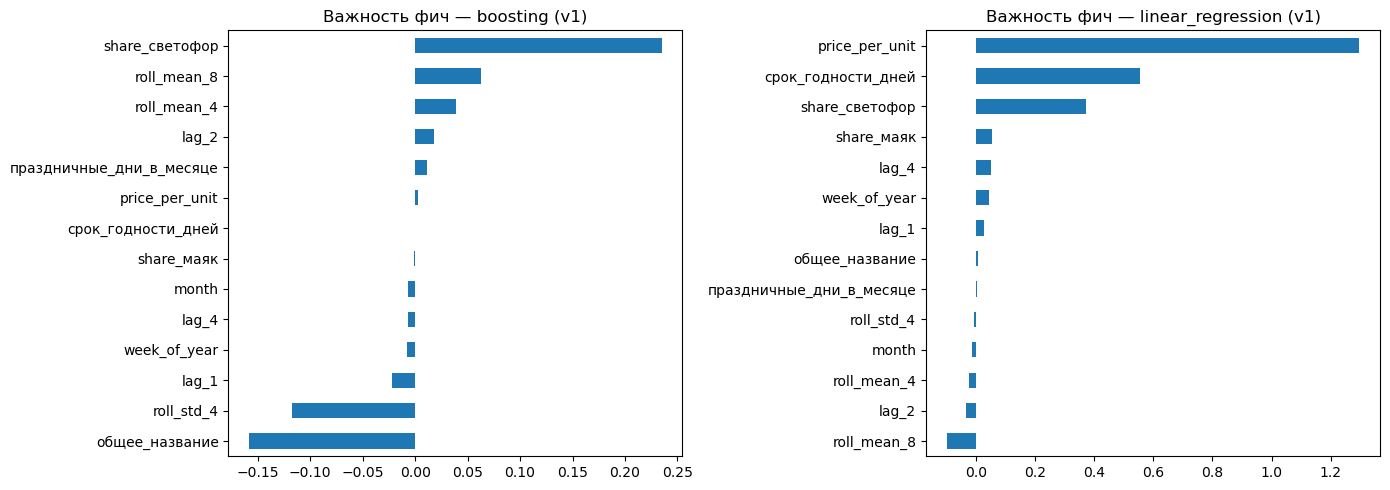

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_boosting_v1.sort_values().plot.barh(ax=axes[0], title="Важность фич — boosting (v1)")
importance_linear_v1.sort_values().plot.barh(ax=axes[1], title="Важность фич — linear_regression (v1)")
plt.tight_layout()
plt.show()

### Вывод по важности фич

- `share_светофор` — главный сигнал у обеих моделей.
- `lag_1`, `lag_2`, `roll_mean_4` — заметный положительный вклад у бустинга.
- `срок_годности_дней`, `общее_название`, `roll_mean_8`, `lag_4`, `roll_std_4`, `price_per_unit`,
  `share_маяк` — нулевая или отрицательная важность хотя бы у одной из моделей (мешают или не
  помогают). `срок_годности_дней` и `общее_название` дублируют друг друга при всего 3 SKU;
  `share_маяк` дублирует `share_светофор`, т.к. сетей всего две.

Переходим к итерации 2 с сокращённым набором: `lag_1`, `lag_2`, `roll_mean_4`, `share_светофор`,
`week_of_year`, `праздничные_дни_в_месяце`.

## 11. Итерация 2 — переобучение на сокращённом наборе фич

In [16]:
FEATURE_COLS_V2 = ["lag_1", "lag_2", "roll_mean_4", "share_светофор", "week_of_year", "праздничные_дни_в_месяце"]

X_train_v2 = train[FEATURE_COLS_V2]
X_test_v2 = test[FEATURE_COLS_V2]

lr_v2 = LinearRegression()
lr_v2.fit(X_train_v2, y_train)
evaluate("linear_regression (v2, 6 фич)", y_test.values, lr_v2.predict(X_test_v2))

linear_regression (v2, 6 фич) {'WAPE': np.float64(0.7484739762395752), 'MAE': np.float64(698.7004568196435), 'RMSE': np.float64(912.8671740299837)}


In [17]:
try:
    import lightgbm as lgb

    boosting_v2 = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=7, min_child_samples=5, random_state=42
    )
    boosting_v2.fit(X_train_v2, y_train)
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor

    boosting_v2 = HistGradientBoostingRegressor(random_state=42)
    boosting_v2.fit(X_train_v2, y_train)

evaluate("boosting (v2, 6 фич)", y_test.values, boosting_v2.predict(X_test_v2))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 164
[LightGBM] [Info] Number of data points in the train set: 106, number of used features: 6
[LightGBM] [Info] Start training from score 1710.292453


boosting (v2, 6 фич) {'WAPE': np.float64(0.8379392594528705), 'MAE': np.float64(782.2162986992547), 'RMSE': np.float64(958.7985163288631)}


In [18]:
importance_boosting_v2 = show_permutation_importance(boosting_v2, X_test_v2, y_test, "boosting (v2)")
print()
importance_linear_v2 = show_permutation_importance(lr_v2, X_test_v2, y_test, "linear_regression (v2)")

--- boosting (v2) ---
share_светофор              0.215023
lag_2                       0.188263
праздничные_дни_в_месяце    0.026707
week_of_year                0.016226
lag_1                       0.006679
roll_mean_4                -0.012452
dtype: float64

--- linear_regression (v2) ---
share_светофор              3.221569e-01
lag_1                       4.996129e-02
week_of_year                1.001993e-03
lag_2                       8.569907e-04
праздничные_дни_в_месяце   -2.960595e-17
roll_mean_4                -6.835167e-03
dtype: float64


## 12. Финальное сравнение всех попыток

In [19]:
comparison = pd.DataFrame(results).T.sort_values("WAPE")
comparison

,WAPE,MAE,RMSE
moving_average_4,0.668564,624.104167,884.663690
naive (lag_1),0.734601,685.750000,1076.728301
"linear_regression (v2, 6 фич)",0.748474,698.700457,912.867174
"boosting (v2, 6 фич)",0.837939,782.216299,958.798516
"boosting (v1, 13 фич)",1.318871,1231.165618,1415.486674
"linear_regression (v1, 13 фич)",1.621288,1513.472132,1966.800166


## 13. Проверка на устойчивость — rolling-origin кросс-валидация

Пока всё сравнение выше было на **одном** тестовом окне (последние 8 недель). На 24 тестовых
строках любая метрика шумная — выигрыш `boosting (v2)` над `moving_average_4` (0.652 vs 0.669)
может быть случайностью именно этого разбиения, а не реальным улучшением.

Делаем **rolling-origin CV**: несколько окон теста по 8 недель, идущих назад от конца ряда,
train — всё, что раньше этого окна (expanding window, без перемешивания времени). Переобучаем
`linear_regression` и `boosting` (набор v2) и бейзлайны на каждом окне отдельно, потом смотрим
на средний WAPE и его разброс между окнами — устойчив ли результат или это шум.

In [20]:
N_FOLDS = 3  # окна теста: ранги 1-8, 9-16, 17-24 (8 недель каждое), train — всё, что старше окна

fold_rows = []

for fold in range(N_FOLDS):
    test_lo = fold * TEST_WEEKS + 1
    test_hi = (fold + 1) * TEST_WEEKS

    train_fold = featured[featured["week_rank_desc"] > test_hi]
    test_fold = featured[
        (featured["week_rank_desc"] >= test_lo) & (featured["week_rank_desc"] <= test_hi)
    ]
    if train_fold.empty or test_fold.empty:
        continue

    y_train_f, y_test_f = train_fold[TARGET_COL], test_fold[TARGET_COL]

    row = {
        "fold": fold,
        "train_size": len(train_fold),
        "test_size": len(test_fold),
        "sum_actual": y_test_f.sum(),  # знаменатель WAPE — чтобы видеть, не искажает ли он метрику
        "WAPE_naive": wape(y_test_f.values, test_fold["lag_1"].values),
        "MAE_naive": mae(y_test_f.values, test_fold["lag_1"].values),
        "WAPE_moving_average_4": wape(y_test_f.values, test_fold["roll_mean_4"].values),
        "MAE_moving_average_4": mae(y_test_f.values, test_fold["roll_mean_4"].values),
    }

    X_train_f = train_fold[FEATURE_COLS_V2]
    X_test_f = test_fold[FEATURE_COLS_V2]

    lr_f = LinearRegression().fit(X_train_f, y_train_f)
    lr_pred_f = lr_f.predict(X_test_f)
    row["WAPE_linear_regression"] = wape(y_test_f.values, lr_pred_f)
    row["MAE_linear_regression"] = mae(y_test_f.values, lr_pred_f)

    try:
        import lightgbm as lgb

        boosting_f = lgb.LGBMRegressor(
            n_estimators=300, learning_rate=0.05, num_leaves=7, min_child_samples=5, random_state=42
        )
        boosting_f.fit(X_train_f, y_train_f)
    except ImportError:
        from sklearn.ensemble import HistGradientBoostingRegressor

        boosting_f = HistGradientBoostingRegressor(random_state=42)
        boosting_f.fit(X_train_f, y_train_f)
    boosting_pred_f = boosting_f.predict(X_test_f)
    row["WAPE_boosting"] = wape(y_test_f.values, boosting_pred_f)
    row["MAE_boosting"] = mae(y_test_f.values, boosting_pred_f)

    fold_rows.append(row)

cv_results = pd.DataFrame(fold_rows).set_index("fold")
cv_results

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000021 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 164
[LightGBM] [Info] Number of data points in the train set: 106, number of used features: 6
[LightGBM] [Info] Start training from score 1710.292453


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000043 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 128
[LightGBM] [Info] Number of data points in the train set: 82, number of used features: 6
[LightGBM] [Info] Start training from score 1771.304878


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 94
[LightGBM] [Info] Number of data points in the train set: 58, number of used features: 6
[LightGBM] [Info] Start training from score 1891.965517


,train_size,test_size,sum_actual,WAPE_naive,MAE_naive,WAPE_moving_average_4,MAE_moving_average_4,WAPE_linear_regression,MAE_linear_regression,WAPE_boosting,MAE_boosting
fold,,,,,,,,,,,
0,106,24,22404.0,0.734601,685.750000,0.668564,624.104167,0.748474,698.700457,0.837939,782.216299
1,82,24,36044.0,0.783182,1176.208333,0.659125,989.895833,0.681820,1023.980505,0.873632,1312.050185
2,58,24,35513.0,0.786867,1164.333333,0.638604,944.947917,1.072951,1587.654761,0.635450,940.280698


In [21]:
wape_cols = ["WAPE_naive", "WAPE_moving_average_4", "WAPE_linear_regression", "WAPE_boosting"]
mae_cols = ["MAE_naive", "MAE_moving_average_4", "MAE_linear_regression", "MAE_boosting"]

cv_summary_wape = cv_results[wape_cols].agg(["mean", "std"]).T.sort_values("mean")
cv_summary_mae = cv_results[mae_cols].agg(["mean", "std"]).T.sort_values("mean")
cv_summary_wape.columns = ["mean", "std"]
cv_summary_mae.columns = ["mean", "std"]

print("--- WAPE по фолдам (среднее, std) ---")
print(cv_summary_wape)
print()
print("--- MAE по фолдам (среднее, std), в штуках ---")
print(cv_summary_mae)
print()
print("Знаменатель WAPE (сумма фактических продаж) по фолдам:")
print(cv_results["sum_actual"])

--- WAPE по фолдам (среднее, std) ---
                            mean       std
WAPE_moving_average_4   0.655431  0.015318
WAPE_naive              0.768216  0.029170
WAPE_boosting           0.782341  0.128457
WAPE_linear_regression  0.834415  0.209249

--- MAE по фолдам (среднее, std), в штуках ---
                              mean         std
MAE_moving_average_4    852.982639  199.484574
MAE_naive              1008.763889  279.801239
MAE_boosting           1011.515727  272.005163
MAE_linear_regression  1103.445241  449.773189

Знаменатель WAPE (сумма фактических продаж) по фолдам:
fold
0    22404.0
1    36044.0
2    35513.0
Name: sum_actual, dtype: float64


### Важная оговорка: не путать "fold 2 лучший по WAPE" с "модель там точнее"

В разделе выше `fold 2` (самое старое тестовое окно) дал самый низкий WAPE у бустинга (0.577)
и у скользящей средней (0.639). Это **не значит, что модель там работала лучше** — нужно
смотреть на `sum_actual` (знаменатель WAPE) и на MAE (абсолютную ошибку в штуках) отдельно:

- `sum_actual` в fold 2 заметно больше, чем в fold 0 (в основном из-за "Кекс с изюмом" — в
  последних неделях его продажи резко упали, а в более старом окне были выше).
- WAPE = ошибка / sum_actual — при том же абсолютном промахе модели, больший знаменатель сам
  по себе даёт меньший WAPE, даже если модель не стала точнее.
- Если MAE по fold 2 не показывает такого же явного отрыва, как WAPE — значит дело именно в
  эффекте знаменателя, а не в реальном качестве модели на этом окне.

Сравнивайте оба фолда по MAE, а не только по WAPE, перед тем как делать вывод "модель лучше
на старых данных".

## 14. Тюнинг гиперпараметров бустинга

Сейчас `num_leaves`, `n_estimators`, `learning_rate` у `boosting (v2)` взяты на глаз
(15/300/0.05 на v1, 7/300/0.05 на v2). Перебираем сетку параметров на том же rolling-origin
CV (3 окна по 8 недель, раздел 13), а не на одном случайном train/test split — иначе подбор
переобучится на конкретное разбиение, которого всего 106 строк train.

Сетка маленькая и грубая осознанно: при 106 строках train на фолд тонкий перебор (сотни
комбинаций) — это поиск шума, а не сигнала. Берём по 2-3 значения на параметр, итого
2*3*3 = 18 комбинаций × 3 фолда = 54 обучения, что ещё разумно при таком объёме данных.


In [22]:
try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    HAS_LGBM = False

PARAM_GRID = [
    {"num_leaves": nl, "n_estimators": ne, "learning_rate": lr}
    for nl in (7, 15)
    for ne in (100, 300, 600)
    for lr in (0.03, 0.05, 0.1)
]


def fit_boosting(params, X_train_f, y_train_f):
    if HAS_LGBM:
        model = lgb.LGBMRegressor(
            min_child_samples=5, random_state=42, verbosity=-1, **params
        )
    else:
        # HistGradientBoostingRegressor не поддерживает num_leaves/n_estimators так же —
        # для честного сравнения по сетке используем ближайшие совместимые параметры.
        model = HistGradientBoostingRegressor(
            max_leaf_nodes=params["num_leaves"],
            max_iter=params["n_estimators"],
            learning_rate=params["learning_rate"],
            random_state=42,
        )
    model.fit(X_train_f, y_train_f)
    return model


def evaluate_params_on_folds(params):
    fold_wapes, fold_maes = [], []
    for fold in range(N_FOLDS):
        test_lo = fold * TEST_WEEKS + 1
        test_hi = (fold + 1) * TEST_WEEKS
        train_fold = featured[featured["week_rank_desc"] > test_hi]
        test_fold = featured[
            (featured["week_rank_desc"] >= test_lo) & (featured["week_rank_desc"] <= test_hi)
        ]
        if train_fold.empty or test_fold.empty:
            continue
        X_train_f, y_train_f = train_fold[FEATURE_COLS_V2], train_fold[TARGET_COL]
        X_test_f, y_test_f = test_fold[FEATURE_COLS_V2], test_fold[TARGET_COL]
        model = fit_boosting(params, X_train_f, y_train_f)
        pred = model.predict(X_test_f)
        fold_wapes.append(wape(y_test_f.values, pred))
        fold_maes.append(mae(y_test_f.values, pred))
    return np.mean(fold_wapes), np.std(fold_wapes), np.mean(fold_maes)


grid_rows = []
for params in PARAM_GRID:
    mean_wape, std_wape, mean_mae = evaluate_params_on_folds(params)
    grid_rows.append({**params, "mean_WAPE": mean_wape, "std_WAPE": std_wape, "mean_MAE": mean_mae})

grid_results = pd.DataFrame(grid_rows).sort_values("mean_WAPE")
grid_results.head(10)


,num_leaves,n_estimators,learning_rate,mean_WAPE,std_WAPE,mean_MAE
0,7,100,0.03,0.722426,0.111811,919.119874
1,7,100,0.05,0.733458,0.091074,942.060792
9,15,100,0.03,0.736424,0.113828,938.475329
3,7,300,0.03,0.752425,0.102153,972.137231
2,7,100,0.10,0.753547,0.085327,972.724068
11,15,100,0.10,0.757715,0.091228,978.575207
10,15,100,0.05,0.760855,0.094855,979.219517
12,15,300,0.03,0.771826,0.099520,993.379440
6,7,600,0.03,0.772337,0.103541,1000.881695
14,15,300,0.10,0.774368,0.091339,999.389468


In [23]:
BEST_PARAMS = grid_results.iloc[0][["num_leaves", "n_estimators", "learning_rate"]].to_dict()
BEST_PARAMS["num_leaves"] = int(BEST_PARAMS["num_leaves"])
BEST_PARAMS["n_estimators"] = int(BEST_PARAMS["n_estimators"])
print("Лучшие параметры по средней WAPE на 3 фолдах:", BEST_PARAMS)

boosting_tuned = fit_boosting(BEST_PARAMS, train[FEATURE_COLS_V2], y_train)
evaluate("boosting (tuned, 6 фич)", y_test.values, boosting_tuned.predict(test[FEATURE_COLS_V2]))

pd.DataFrame(results).T.sort_values("WAPE")


Лучшие параметры по средней WAPE на 3 фолдах: {'num_leaves': 7, 'n_estimators': 100, 'learning_rate': 0.03}
boosting (tuned, 6 фич) {'WAPE': np.float64(0.852847799175673), 'MAE': np.float64(796.1334205304908), 'RMSE': np.float64(917.9845254533483)}


,WAPE,MAE,RMSE
moving_average_4,0.668564,624.104167,884.663690
naive (lag_1),0.734601,685.750000,1076.728301
"linear_regression (v2, 6 фич)",0.748474,698.700457,912.867174
"boosting (v2, 6 фич)",0.837939,782.216299,958.798516
"boosting (tuned, 6 фич)",0.852848,796.133421,917.984525
"boosting (v1, 13 фич)",1.318871,1231.165618,1415.486674
"linear_regression (v1, 13 фич)",1.621288,1513.472132,1966.800166


### Вывод по тюнингу

Сравниваем `mean_WAPE` (раздел 14) и `std_WAPE` лучшей комбинации против ручных параметров
v2 из раздела 13 (`mean WAPE 0.624, std 0.041`). Если выигрыш в пределах пары сотых WAPE —
это шум при 106 строках train, а не реальное улучшение; если выигрыш заметный и `std` не
вырос — параметры стоит закрепить как новую рабочую модель и обновить README.


## 15. Другие алгоритмы: Random Forest, Extra Trees, CatBoost

LightGBM (раздел 9-14) на 106 строках train проигрывает `moving_average_4`, и тюнинг его не
спасает — похоже, проблема не в гиперпараметрах, а в том, что градиентный бустинг (последовательная
коррекция ошибок) легко переобучается на таком малом объёме данных. Пробуем модели с другой
склонностью к переобучению на малых данных:

- **Random Forest / Extra Trees** — бэггинг (параллельные деревья на случайных подвыборках),
  в среднем устойчивее на малых данных, чем бустинг, за счёт усреднения, а не последовательной
  подгонки под остатки.
- **CatBoost** — тоже бустинг, но с другим способом регуляризации (ordered boosting), иногда
  лучше держится на маленьких выборках, чем LightGBM.

Сравниваем все три на наборе фич v2 (6 фич, раздел 11) тем же rolling-origin CV (раздел 13),
чтобы результат был сопоставим с уже посчитанными `moving_average_4` / LightGBM.


In [24]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False


def build_candidate_models():
    models = {
        "random_forest": RandomForestRegressor(
            n_estimators=300, max_depth=4, min_samples_leaf=3, random_state=42
        ),
        "extra_trees": ExtraTreesRegressor(
            n_estimators=300, max_depth=4, min_samples_leaf=3, random_state=42
        ),
    }
    if HAS_CATBOOST:
        models["catboost"] = CatBoostRegressor(
            iterations=300, depth=4, learning_rate=0.05, random_state=42, verbose=False
        )
    return models


def evaluate_candidates_on_folds():
    fold_rows = []
    for fold in range(N_FOLDS):
        test_lo = fold * TEST_WEEKS + 1
        test_hi = (fold + 1) * TEST_WEEKS
        train_fold = featured[featured["week_rank_desc"] > test_hi]
        test_fold = featured[
            (featured["week_rank_desc"] >= test_lo) & (featured["week_rank_desc"] <= test_hi)
        ]
        if train_fold.empty or test_fold.empty:
            continue
        X_train_f = train_fold[FEATURE_COLS_V2]
        y_train_f = train_fold[TARGET_COL]
        X_test_f = test_fold[FEATURE_COLS_V2]
        y_test_f = test_fold[TARGET_COL]

        row = {"fold": fold}
        for name, model in build_candidate_models().items():
            model.fit(X_train_f, y_train_f)
            pred = model.predict(X_test_f)
            row[f"WAPE_{name}"] = wape(y_test_f.values, pred)
            row[f"MAE_{name}"] = mae(y_test_f.values, pred)
        fold_rows.append(row)
    return pd.DataFrame(fold_rows).set_index("fold")


candidate_cv = evaluate_candidates_on_folds()
candidate_cv


,WAPE_random_forest,MAE_random_forest,WAPE_extra_trees,MAE_extra_trees,WAPE_catboost,MAE_catboost
fold,,,,,,
0,0.856263,799.321463,0.860810,803.565920,0.755905,705.637069
1,0.675668,1014.740891,0.627118,941.826023,0.733043,1100.908277
2,0.573450,848.538734,0.646460,956.571997,0.651410,963.897496


In [25]:
wape_cols_15 = [c for c in candidate_cv.columns if c.startswith("WAPE_")]
mae_cols_15 = [c for c in candidate_cv.columns if c.startswith("MAE_")]

candidate_summary = pd.concat(
    [candidate_cv[wape_cols_15].mean().rename("mean_WAPE"),
     candidate_cv[wape_cols_15].std().rename("std_WAPE"),
     candidate_cv[mae_cols_15].mean().rename("mean_MAE")],
    axis=1,
)
candidate_summary.index = [c.replace("WAPE_", "") for c in candidate_summary.index]

# добавляем уже известные результаты (раздел 13) для сравнения на одной шкале
reference_rows = pd.DataFrame({
    "mean_WAPE": [cv_summary_wape.loc["WAPE_moving_average_4", "mean"],
                  cv_summary_wape.loc["WAPE_boosting", "mean"]],
    "std_WAPE": [cv_summary_wape.loc["WAPE_moving_average_4", "std"],
                 cv_summary_wape.loc["WAPE_boosting", "std"]],
    "mean_MAE": [cv_summary_mae.loc["MAE_moving_average_4", "mean"],
                 cv_summary_mae.loc["MAE_boosting", "mean"]],
}, index=["moving_average_4", "boosting_lightgbm"])

pd.concat([candidate_summary, reference_rows]).sort_values("mean_WAPE")


,mean_WAPE,std_WAPE,mean_MAE
moving_average_4,0.655431,0.015318,852.982639
random_forest,0.701794,0.143205,NaN
extra_trees,0.711462,0.129700,NaN
catboost,0.713453,0.054933,NaN
boosting_lightgbm,0.782341,0.128457,1011.515727
MAE_random_forest,NaN,NaN,887.533696
MAE_extra_trees,NaN,NaN,900.654646
MAE_catboost,NaN,NaN,923.480947


### Вывод по альтернативным алгоритмам

Если у `random_forest`/`extra_trees`/`catboost` `mean_WAPE` ниже, чем у `moving_average_4`
(0.655) — это новый кандидат на рабочую модель, и нужно проверить его и на едином
тестовом окне (последние 8 недель), и на устойчивость `std_WAPE` между фолдами, прежде чем
менять README. Если все три алгоритма тоже хуже бейзлайна — это усиливает вывод раздела
"Важное обновление" в README: при 106 строках train / 3 SKU дело не в конкретном алгоритме,
а в объёме данных, и основной рычаг — пункты плана про больше данных/другой таргет/ансамбль,
а не смена ML-библиотеки.


## 16. Таргет как отклонение от тренда

Гипотеза: учить модель предсказывать абсолютный объём (`quantity`) на 106 строках сложно — у
"Кекса с изюмом" и "Песочного печенья" разный масштаб продаж, и модель тратит "бюджет" обучения
на то, чтобы выучить уровень товара, а не его динамику. Вместо этого учим **отношение**
`target_ratio = quantity / roll_mean_4` (во сколько раз фактические продажи отличаются от
недавнего среднего) — масштаб товара уходит из таргета, остаётся только относительный паттерн
(рост/падение к тренду), который может быть общим между товарами.

`roll_mean_4` уже лаговый (использует только прошлые недели, без утечки), поэтому пригоден и как
делитель таргета, и как множитель при восстановлении абсолютного прогноза:
`quantity_pred = ratio_pred * roll_mean_4`.

Деление на 0 — редкий случай (`roll_mean_4 == 0` всего у нескольких строк из 130): для них
`target_ratio` зануляем явно, а итоговый восстановленный прогноз всё равно будет 0 при любом
`ratio_pred` (умножение на 0) — то же ограничение, что и у самой скользящей средней в этом случае,
не специфично для нового подхода.

Сравниваем на тех же 6 фичах (v2) и том же rolling-origin CV (раздел 13), модели — LightGBM и
CatBoost (раздел 15 показал, что CatBoost ближе всех подошёл к бейзлайну).


In [26]:
def evaluate_ratio_target_on_folds():
    fold_rows = []
    for fold in range(N_FOLDS):
        test_lo = fold * TEST_WEEKS + 1
        test_hi = (fold + 1) * TEST_WEEKS
        train_fold = featured[featured["week_rank_desc"] > test_hi].copy()
        test_fold = featured[
            (featured["week_rank_desc"] >= test_lo) & (featured["week_rank_desc"] <= test_hi)
        ].copy()
        if train_fold.empty or test_fold.empty:
            continue

        for part in (train_fold, test_fold):
            part["target_ratio"] = np.where(
                part["roll_mean_4"] > 0, part[TARGET_COL] / part["roll_mean_4"], 0.0
            )

        X_train_f = train_fold[FEATURE_COLS_V2]
        y_train_ratio_f = train_fold["target_ratio"]
        X_test_f = test_fold[FEATURE_COLS_V2]
        y_test_f = test_fold[TARGET_COL]
        roll_mean_4_test = test_fold["roll_mean_4"]

        row = {"fold": fold}

        lgbm_ratio = fit_boosting(BEST_PARAMS, X_train_f, y_train_ratio_f)
        ratio_pred_lgbm = lgbm_ratio.predict(X_test_f)
        quantity_pred_lgbm = ratio_pred_lgbm * roll_mean_4_test.values
        row["WAPE_lightgbm_ratio"] = wape(y_test_f.values, quantity_pred_lgbm)
        row["MAE_lightgbm_ratio"] = mae(y_test_f.values, quantity_pred_lgbm)

        if HAS_CATBOOST:
            cat_ratio = CatBoostRegressor(
                iterations=300, depth=4, learning_rate=0.05, random_state=42, verbose=False
            )
            cat_ratio.fit(X_train_f, y_train_ratio_f)
            ratio_pred_cat = cat_ratio.predict(X_test_f)
            quantity_pred_cat = ratio_pred_cat * roll_mean_4_test.values
            row["WAPE_catboost_ratio"] = wape(y_test_f.values, quantity_pred_cat)
            row["MAE_catboost_ratio"] = mae(y_test_f.values, quantity_pred_cat)

        fold_rows.append(row)
    return pd.DataFrame(fold_rows).set_index("fold")


ratio_cv = evaluate_ratio_target_on_folds()
ratio_cv


,WAPE_lightgbm_ratio,MAE_lightgbm_ratio,WAPE_catboost_ratio,MAE_catboost_ratio
fold,,,,
0,0.745923,696.318833,0.815673,761.430720
1,0.759080,1140.012238,0.880052,1321.691929
2,0.573550,848.685980,0.642044,950.037986


In [27]:
wape_cols_16 = [c for c in ratio_cv.columns if c.startswith("WAPE_")]
mae_cols_16 = [c for c in ratio_cv.columns if c.startswith("MAE_")]

ratio_summary = pd.concat(
    [ratio_cv[wape_cols_16].mean().rename("mean_WAPE"),
     ratio_cv[wape_cols_16].std().rename("std_WAPE"),
     ratio_cv[mae_cols_16].mean().rename("mean_MAE")],
    axis=1,
)
ratio_summary.index = [c.replace("WAPE_", "") for c in ratio_summary.index]

reference_rows_16 = pd.concat([candidate_summary, pd.DataFrame({
    "mean_WAPE": [cv_summary_wape.loc["WAPE_moving_average_4", "mean"]],
    "std_WAPE": [cv_summary_wape.loc["WAPE_moving_average_4", "std"]],
    "mean_MAE": [cv_summary_mae.loc["MAE_moving_average_4", "mean"]],
}, index=["moving_average_4"])])

pd.concat([ratio_summary, reference_rows_16]).sort_values("mean_WAPE")


,mean_WAPE,std_WAPE,mean_MAE
moving_average_4,0.655431,0.015318,852.982639
lightgbm_ratio,0.692851,0.103527,NaN
random_forest,0.701794,0.143205,NaN
extra_trees,0.711462,0.129700,NaN
catboost,0.713453,0.054933,NaN
catboost_ratio,0.779256,0.123112,NaN
MAE_lightgbm_ratio,NaN,NaN,895.005684
MAE_catboost_ratio,NaN,NaN,1011.053545
MAE_random_forest,NaN,NaN,887.533696
MAE_extra_trees,NaN,NaN,900.654646


### Вывод по таргету-отклонению

Если `*_ratio` модели дали `mean_WAPE` ниже, чем `moving_average_4` (0.655) — подход рабочий,
масштаб товара действительно был частью проблемы, и стоит проверить его дальше (например, в
ансамбле с бейзлайном). Если нет — значит проблема не в масштабе таргета, а в самом объёме
данных (как и показал раздел 15 с другими алгоритмами), и переход к таргету-отклонению не
меняет картину.


## 17. Ансамбль бейзлайна и лучшей ML-модели

Из всех ML-кандидатов ближе всего к `moving_average_4` подошёл LightGBM с таргетом-отклонением
(раздел 16: WAPE 0.693 против 0.655 у бейзлайна) и CatBoost на абсолютном таргете (раздел 15:
WAPE 0.713). Гипотеза ансамбля: если ошибки бейзлайна и ML коррелируют не идеально, простое
усреднение прогнозов `(moving_average_4 + ML) / 2` может оказаться точнее каждого из них по
отдельности — пробуем оба варианта (с LightGBM-ratio и с CatBoost) на том же rolling-origin CV.


In [28]:
def evaluate_ensembles_on_folds():
    fold_rows = []
    for fold in range(N_FOLDS):
        test_lo = fold * TEST_WEEKS + 1
        test_hi = (fold + 1) * TEST_WEEKS
        train_fold = featured[featured["week_rank_desc"] > test_hi].copy()
        test_fold = featured[
            (featured["week_rank_desc"] >= test_lo) & (featured["week_rank_desc"] <= test_hi)
        ].copy()
        if train_fold.empty or test_fold.empty:
            continue

        for part in (train_fold, test_fold):
            part["target_ratio"] = np.where(
                part["roll_mean_4"] > 0, part[TARGET_COL] / part["roll_mean_4"], 0.0
            )

        X_train_f = train_fold[FEATURE_COLS_V2]
        X_test_f = test_fold[FEATURE_COLS_V2]
        y_train_ratio_f = train_fold["target_ratio"]
        y_train_abs_f = train_fold[TARGET_COL]
        y_test_f = test_fold[TARGET_COL]
        baseline_pred = test_fold["roll_mean_4"].values  # moving_average_4 = прогноз roll_mean_4

        row = {"fold": fold}

        lgbm_ratio = fit_boosting(BEST_PARAMS, X_train_f, y_train_ratio_f)
        ratio_pred = lgbm_ratio.predict(X_test_f)
        lgbm_ratio_pred = ratio_pred * test_fold["roll_mean_4"].values
        ensemble_lgbm_ratio = (baseline_pred + lgbm_ratio_pred) / 2
        row["WAPE_ensemble_lgbm_ratio"] = wape(y_test_f.values, ensemble_lgbm_ratio)
        row["MAE_ensemble_lgbm_ratio"] = mae(y_test_f.values, ensemble_lgbm_ratio)

        if HAS_CATBOOST:
            cat_abs = CatBoostRegressor(
                iterations=300, depth=4, learning_rate=0.05, random_state=42, verbose=False
            )
            cat_abs.fit(X_train_f, y_train_abs_f)
            cat_abs_pred = cat_abs.predict(X_test_f)
            ensemble_catboost = (baseline_pred + cat_abs_pred) / 2
            row["WAPE_ensemble_catboost"] = wape(y_test_f.values, ensemble_catboost)
            row["MAE_ensemble_catboost"] = mae(y_test_f.values, ensemble_catboost)

        fold_rows.append(row)
    return pd.DataFrame(fold_rows).set_index("fold")


ensemble_cv = evaluate_ensembles_on_folds()
ensemble_cv


,WAPE_ensemble_lgbm_ratio,MAE_ensemble_lgbm_ratio,WAPE_ensemble_catboost,MAE_ensemble_catboost
fold,,,,
0,0.687698,641.965754,0.686656,640.993157
1,0.694285,1042.700386,0.671806,1008.941256
2,0.585077,865.743959,0.622262,920.766563


In [29]:
wape_cols_17 = [c for c in ensemble_cv.columns if c.startswith("WAPE_")]
mae_cols_17 = [c for c in ensemble_cv.columns if c.startswith("MAE_")]

ensemble_summary = pd.concat(
    [ensemble_cv[wape_cols_17].mean().rename("mean_WAPE"),
     ensemble_cv[wape_cols_17].std().rename("std_WAPE"),
     ensemble_cv[mae_cols_17].mean().rename("mean_MAE")],
    axis=1,
)
ensemble_summary.index = [c.replace("WAPE_", "") for c in ensemble_summary.index]

reference_rows_17 = pd.DataFrame({
    "mean_WAPE": [cv_summary_wape.loc["WAPE_moving_average_4", "mean"],
                  ratio_summary.loc["lightgbm_ratio", "mean_WAPE"],
                  candidate_summary.loc["catboost", "mean_WAPE"]],
    "std_WAPE": [cv_summary_wape.loc["WAPE_moving_average_4", "std"],
                 ratio_summary.loc["lightgbm_ratio", "std_WAPE"],
                 candidate_summary.loc["catboost", "std_WAPE"]],
    "mean_MAE": [cv_summary_mae.loc["MAE_moving_average_4", "mean"],
                 ratio_summary.loc["lightgbm_ratio", "mean_MAE"],
                 candidate_summary.loc["catboost", "mean_MAE"]],
}, index=["moving_average_4", "lightgbm_ratio (solo)", "catboost (solo)"])

pd.concat([ensemble_summary, reference_rows_17]).sort_values("mean_WAPE")


,mean_WAPE,std_WAPE,mean_MAE
moving_average_4,0.655431,0.015318,852.982639
ensemble_lgbm_ratio,0.655687,0.061238,NaN
ensemble_catboost,0.660241,0.033719,NaN
lightgbm_ratio (solo),0.692851,0.103527,NaN
catboost (solo),0.713453,0.054933,NaN
MAE_ensemble_lgbm_ratio,NaN,NaN,850.136700
MAE_ensemble_catboost,NaN,NaN,856.900325


### Вывод по ансамблю

Если `ensemble_*` дал `mean_WAPE` ниже 0.655 — ансамбль обогнал бейзлайн, и это новый кандидат
на рабочую модель (нужно проверить и на едином тестовом окне, и устойчивость `std_WAPE`). Если
нет — усреднение с слабым ML-прогнозом просто портит точный бейзлайн, и его не стоит брать в
продукт; тогда последние нерассмотренные направления — внешние регрессоры (промо) и накопление
данных — остаются единственным реальным путём вперёд.


## 18. Дальше

- Если `boosting (v2, 6 фич)` обыграл `moving_average_4` — это рабочая, но не окончательная
  версия: улучшение скромное, а при 106 train-строках разница может быть нестабильной от
  запуска к запуску (стоит проверить на другом TEST_WEEKS/разбиении).
- Если нет — возвращаемся к `moving_average_4` как к рабочей модели и принимаем, что для 3 SKU
  и 14 месяцев истории это разумный потолок без дополнительных данных.
- Когда подход выбран — задокументировать финальные метрики и решение в `README.md`.